# Projet de prédiction de survie hospitalière — notebook refait proprement

Ce notebook reprend le projet **de A à Z** avec un objectif clair :

1. charger les données sans erreur de parsing ;
2. faire une exploration raisonnable sans saturer la mémoire ;
3. construire un pipeline cohérent de prétraitement ;
4. comparer quelques modèles **légers et robustes** ;
5. évaluer proprement le meilleur modèle ;
6. générer un fichier de prédiction pour le jeu de test.

Le notebook est volontairement pensé pour **éviter les crashs du kernel** :
- pas de copie inutile de gros DataFrames ;
- pas de validation croisée trop lourde ;
- pas de recherche d’hyperparamètres massive ;
- possibilité de travailler sur un **sous-échantillon contrôlé** pour la comparaison des modèles.

In [1]:
# =========================
# 1. Imports et configuration
# =========================
from pathlib import Path
import warnings
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.metrics import (
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import ExtraTreesClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 3

# Pour comparer les modèles sans faire exploser le kernel :
MODEL_SELECTION_SAMPLE = 20000

# Pour l'entraînement final :
# None  -> on prend tout le dataset
# entier -> on limite volontairement la taille
FINAL_FIT_SAMPLE = None

# Adapter si les fichiers sont ailleurs
DATA = Path("/home/imal/ICU-Survival-Prediction-End-to-End-ML-Pipeline/data/public_data")

## 2. Fonctions utilitaires

Les fonctions suivantes servent à :
- charger correctement les fichiers du challenge ;
- convertir les colonnes selon le fichier `feat.type` ;
- créer quelques variables utiles à partir des dates ;
- séparer les groupes de variables ;
- évaluer plusieurs modèles sans dupliquer du code.

In [2]:
def load_metadata(data_dir: Path):
    feature_names = pd.read_csv(data_dir / "mimic_synthetic_feat.name", header=None)[0].tolist()
    feature_types = pd.read_csv(data_dir / "mimic_synthetic_feat.type", header=None)[0].tolist()
    label_name = pd.read_csv(data_dir / "mimic_synthetic_label.name", header=None)[0].iloc[0]
    feature_type_map = dict(zip(feature_names, feature_types))
    return feature_names, feature_type_map, label_name


def load_raw_table(path: Path, feature_names):
    return pd.read_csv(
        path,
        sep=r"\s+",
        header=None,
        names=feature_names,
        engine="python",
        dtype=str,
    )


def cast_columns_from_metadata(df: pd.DataFrame, feature_type_map: dict):
    for col, typ in feature_type_map.items():
        if typ in {"Numerical", "Binary"} and col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
        elif col in df.columns:
            df[col] = df[col].astype("string")
    return df


def engineer_features(df: pd.DataFrame):
    out = df.copy()

    admit_dt = pd.to_datetime(out["ADMITTIME"], format="%Y-%m-%d_%H:%M:%S", errors="coerce")
    disch_dt = pd.to_datetime(out["DISCHTIME"], format="%Y-%m-%d_%H:%M:%S", errors="coerce")

    extra = pd.DataFrame(
        {
            "LENGTH_OF_STAY_DAYS": (disch_dt - admit_dt).dt.total_seconds() / 86400.0,
            "ADMIT_HOUR": admit_dt.dt.hour,
            "ADMIT_DAYOFWEEK": admit_dt.dt.dayofweek,
            "ADMIT_MONTH": admit_dt.dt.month,
            "ADMIT_YEAR": admit_dt.dt.year,
        },
        index=out.index,
    )

    out = out.drop(columns=["SUBJECT_ID", "HADM_ID", "ADMITTIME", "DISCHTIME"], errors="ignore")
    out = pd.concat([out, extra], axis=1)

    return out


def get_feature_groups(df: pd.DataFrame, feature_type_map: dict):
    categorical_cols = [
        c for c, t in feature_type_map.items()
        if t == "Categorical" and c in df.columns
    ]
    numerical_cols = [c for c in df.columns if c not in categorical_cols]
    return numerical_cols, categorical_cols


def subsample_stratified(X: pd.DataFrame, y: pd.Series, n_rows: int, random_state: int = 42):
    if n_rows is None or n_rows >= len(X):
        return X, y

    sample_size_class1 = int(round(n_rows * y.mean()))
    sample_size_class0 = n_rows - sample_size_class1

    idx_1 = y[y == 1].sample(n=min(sample_size_class1, (y == 1).sum()), random_state=random_state).index
    idx_0 = y[y == 0].sample(n=min(sample_size_class0, (y == 0).sum()), random_state=random_state).index
    idx = idx_0.union(idx_1)
    return X.loc[idx].sort_index(), y.loc[idx].sort_index()


def evaluate_models(models: dict, X: pd.DataFrame, y: pd.Series, cv_folds: int = 3):
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
    rows = []

    for name, model in models.items():
        scores = cross_validate(
            model,
            X,
            y,
            cv=cv,
            scoring={"bal_acc": "balanced_accuracy", "roc_auc": "roc_auc"},
            n_jobs=1,
            return_train_score=False,
        )

        rows.append(
            {
                "model": name,
                "bal_acc_mean": scores["test_bal_acc"].mean(),
                "bal_acc_std": scores["test_bal_acc"].std(),
                "roc_auc_mean": scores["test_roc_auc"].mean(),
                "roc_auc_std": scores["test_roc_auc"].std(),
            }
        )

    return pd.DataFrame(rows).sort_values("bal_acc_mean", ascending=False).reset_index(drop=True)


def find_best_threshold(y_true, y_score, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 91)

    rows = []
    for thr in thresholds:
        y_pred = (y_score >= thr).astype(int)
        rows.append(
            {
                "threshold": thr,
                "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            }
        )

    thr_df = pd.DataFrame(rows)
    best_row = thr_df.loc[thr_df["balanced_accuracy"].idxmax()]
    return best_row["threshold"], thr_df

## 3. Chargement des données

In [3]:
feature_names, feature_type_map, label_name = load_metadata(DATA)

X_train_raw = load_raw_table(DATA / "mimic_synthetic_train.data", feature_names)
X_test_raw = load_raw_table(DATA / "mimic_synthetic_test.data", feature_names)
y = pd.read_csv(DATA / "mimic_synthetic_train.solution", header=None)[0].astype(int)

print("Train brut :", X_train_raw.shape)
print("Test brut  :", X_test_raw.shape)
print("Taux de décès :", round(y.mean() * 100, 2), "%")
print("Nom de la cible :", label_name)

Train brut : (79999, 341)
Test brut  : (20001, 341)
Taux de décès : 3.5 %
Nom de la cible : DIED


## 4. Conversion propre des types

In [4]:
X_train_raw = cast_columns_from_metadata(X_train_raw, feature_type_map)
X_test_raw = cast_columns_from_metadata(X_test_raw, feature_type_map)

display(X_train_raw.head(3))
print(X_train_raw.dtypes.value_counts())

,SUBJECT_ID,HADM_ID,ADMITTIME,DISCHTIME,INSURANCE,LANGUAGE,RELIGION,MARITAL_STATUS,ETHNICITY,GENDER,...,Eyeinfectn,Othereyedx,Otitismedia,Dizziness,Othereardx,Othnervdx,Hrtvalvedx,Carditis,HTN,Htncomplicn
0,45524,108398,2128-05-15_23:42:00,2132-07-23_15:00:00,Private,ENGL,CATHOLIC,DIVORCED,WHITE,NaN,...,0,0,0,0,0.0,0.0,0,0,0,0.0
1,50520,186416,2134-03-17_03:59:00,2113-03-06_12:05:00,Private,ENGL,UNOBTAINABLE,SINGLE,WHITE,NaN,...,0,0,0,0,0.0,0.0,0,0,0,1.0
2,17956,126413,2164-04-05_17:32:00,2180-09-20_16:30:00,Medicaid,SPAN,CATHOLIC,WIDOWED,OTHER,NaN,...,0,0,0,0,0.0,0.0,0,0,0,0.0


int64             276
float64            57
string[python]      8
Name: count, dtype: int64


## 5. Analyse exploratoire

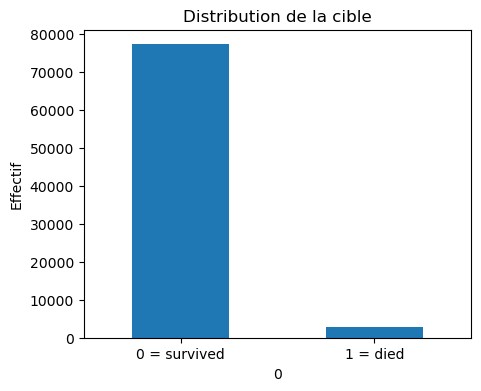

Classe majoritaire : 0.9650370629632871


In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
y.value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_xticklabels(["0 = survived", "1 = died"], rotation=0)
ax.set_title("Distribution de la cible")
ax.set_ylabel("Effectif")
plt.show()

print("Classe majoritaire :", y.value_counts(normalize=True).sort_values(ascending=False).iloc[0])

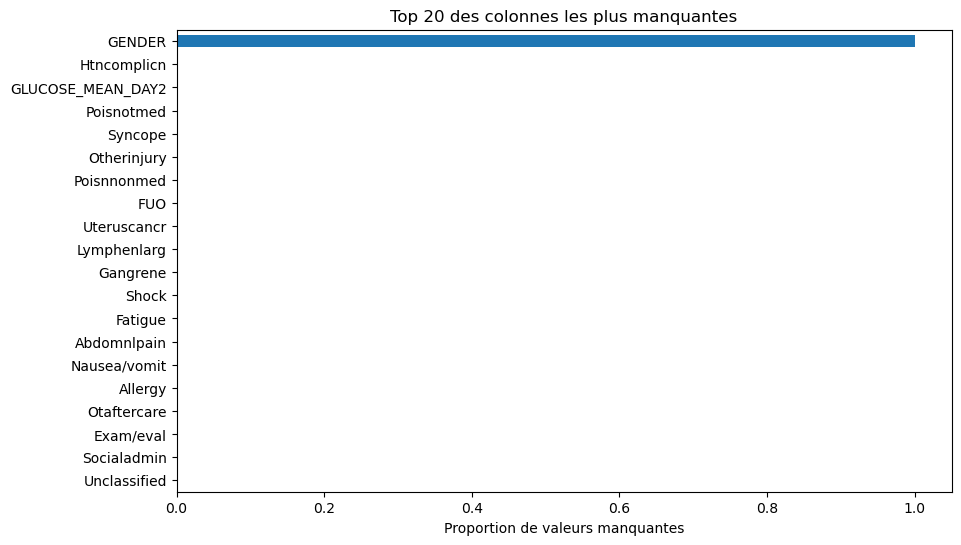

,missing_rate
GENDER,0.999975
Htncomplicn,0.000163
GLUCOSE_MEAN_DAY2,0.000025
Unclassified,0.000000
Otaftercare,0.000000
Exam/eval,0.000000
Socialadmin,0.000000
Allergy,0.000000
Fatigue,0.000000
Abdomnlpain,0.000000


In [6]:
missing_rate = X_train_raw.isna().mean().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
missing_rate.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top 20 des colonnes les plus manquantes")
ax.set_xlabel("Proportion de valeurs manquantes")
plt.show()

display(missing_rate.to_frame("missing_rate"))

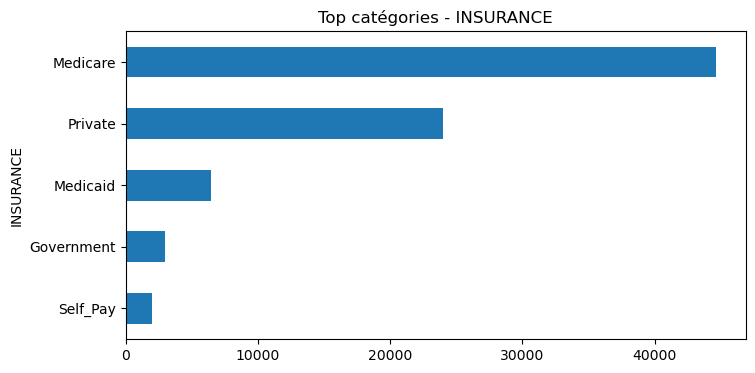

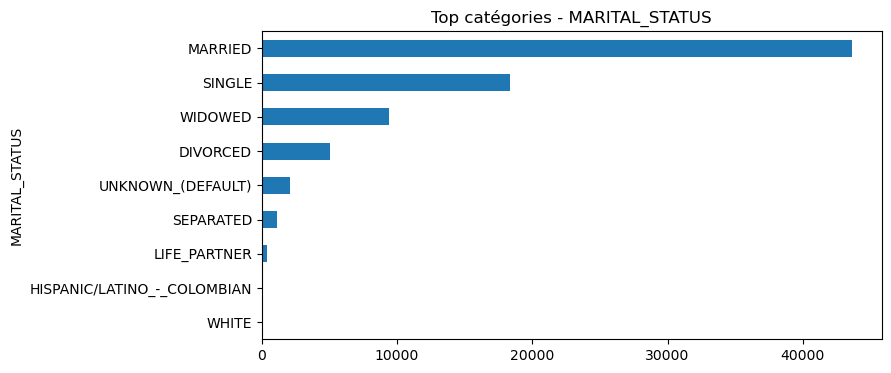

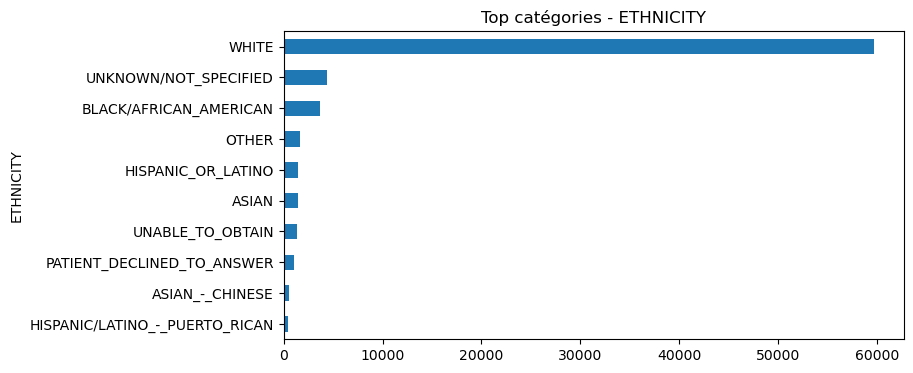

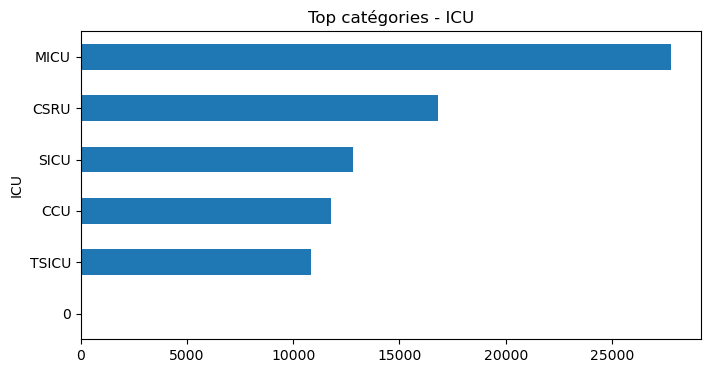

In [7]:
categorical_candidates = ["INSURANCE", "MARITAL_STATUS", "ETHNICITY", "ICU"]

for col in categorical_candidates:
    if col in X_train_raw.columns:
        fig, ax = plt.subplots(figsize=(8, 4))
        (
            X_train_raw[col]
            .astype("string")
            .fillna("MISSING")
            .value_counts()
            .head(10)
            .sort_values()
            .plot(kind="barh", ax=ax)
        )
        ax.set_title(f"Top catégories - {col}")
        plt.show()

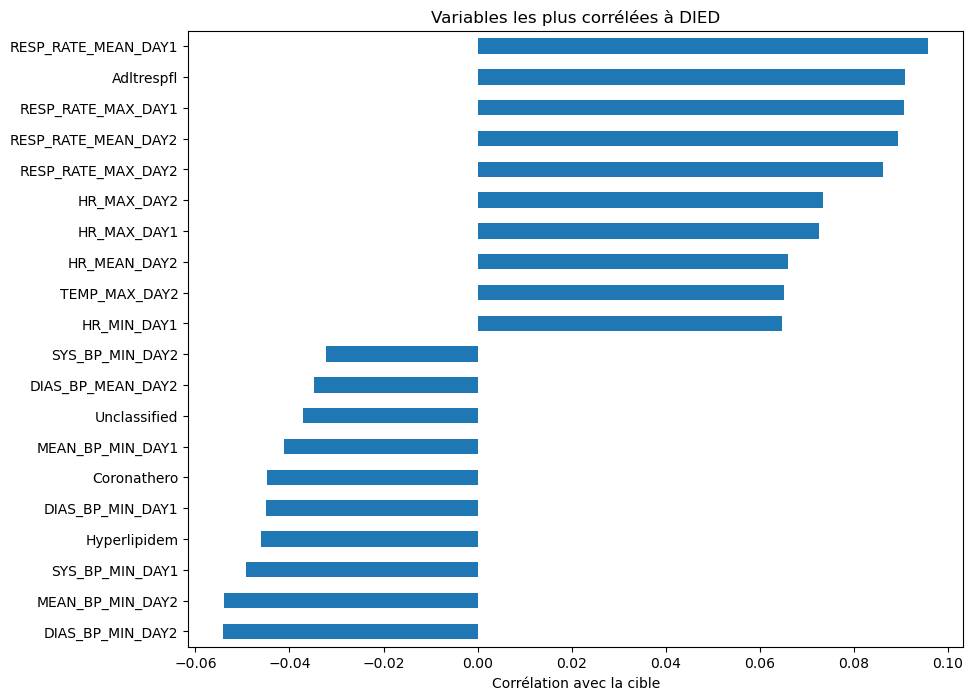

,correlation
DIAS_BP_MIN_DAY2,-0.054025
MEAN_BP_MIN_DAY2,-0.053920
SYS_BP_MIN_DAY1,-0.049327
Hyperlipidem,-0.046056
DIAS_BP_MIN_DAY1,-0.044913
Coronathero,-0.044669
MEAN_BP_MIN_DAY1,-0.041193
Unclassified,-0.037024
DIAS_BP_MEAN_DAY2,-0.034783
SYS_BP_MIN_DAY2,-0.032270


In [8]:
numeric_cols_raw = [
    c for c, t in feature_type_map.items()
    if t in {"Numerical", "Binary"} and c in X_train_raw.columns
]

corr_series = X_train_raw[numeric_cols_raw].corrwith(y).dropna().sort_values()
top_corr = pd.concat([corr_series.head(10), corr_series.tail(10)])

fig, ax = plt.subplots(figsize=(10, 8))
top_corr.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Variables les plus corrélées à DIED")
ax.set_xlabel("Corrélation avec la cible")
plt.show()

display(top_corr.to_frame("correlation"))

## 6. Prétraitement et création de variables

In [9]:
X = engineer_features(X_train_raw)
X_test = engineer_features(X_test_raw)

num_cols, cat_cols = get_feature_groups(X, feature_type_map)

print("Shape train après feature engineering :", X.shape)
print("Shape test  après feature engineering :", X_test.shape)
print("Variables numériques :", len(num_cols))
print("Variables catégorielles :", len(cat_cols))

Shape train après feature engineering : (79999, 342)
Shape test  après feature engineering : (20001, 342)
Variables numériques : 336
Variables catégorielles : 6


In [10]:
X_dev, X_valid, y_dev, y_valid = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("X_dev  :", X_dev.shape)
print("X_valid:", X_valid.shape)
print("Taux décès train :", round(y_dev.mean(), 4))
print("Taux décès valid :", round(y_valid.mean(), 4))

X_dev  : (63999, 342)
X_valid: (16000, 342)
Taux décès train : 0.035
Taux décès valid : 0.0349


## 7. Pipelines de prétraitement

In [11]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            num_cols,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            cat_cols,
        ),
    ],
    remainder="drop",
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            num_cols,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
                ]
            ),
            cat_cols,
        ),
    ],
    remainder="drop",
)

## 8. Sous-échantillon pour la comparaison des modèles

In [12]:
X_bench, y_bench = subsample_stratified(
    X_dev,
    y_dev,
    n_rows=MODEL_SELECTION_SAMPLE,
    random_state=RANDOM_STATE,
)

print("Taille du benchmark :", X_bench.shape)
print("Taux de décès benchmark :", round(y_bench.mean(), 4))

Taille du benchmark : (20000, 342)
Taux de décès benchmark : 0.035


## 9. Modèles comparés

In [13]:
models = {
    "dummy_most_frequent": Pipeline(
        steps=[
            ("prep", linear_preprocessor),
            ("model", DummyClassifier(strategy="most_frequent")),
        ]
    ),
    "sgd_log_loss_balanced": Pipeline(
        steps=[
            ("prep", linear_preprocessor),
            (
                "model",
                SGDClassifier(
                    loss="log_loss",
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    max_iter=1500,
                    tol=1e-3,
                ),
            ),
        ]
    ),
    "extra_trees_balanced": Pipeline(
        steps=[
            ("prep", tree_preprocessor),
            (
                "model",
                ExtraTreesClassifier(
                    n_estimators=250,
                    max_depth=16,
                    min_samples_leaf=2,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    "ros_plus_sgd": ImbPipeline(
        steps=[
            ("prep", linear_preprocessor),
            ("ros", RandomOverSampler(random_state=RANDOM_STATE)),
            (
                "model",
                SGDClassifier(
                    loss="log_loss",
                    random_state=RANDOM_STATE,
                    max_iter=1500,
                    tol=1e-3,
                ),
            ),
        ]
    ),
}

,model,bal_acc_mean,bal_acc_std,roc_auc_mean,roc_auc_std
0,ros_plus_sgd,0.740146,0.010609,0.799634,0.009120
1,sgd_log_loss_balanced,0.679541,0.034223,0.737890,0.035060
2,extra_trees_balanced,0.516930,0.002833,0.720976,0.009989
3,dummy_most_frequent,0.500000,0.000000,0.500000,0.000000


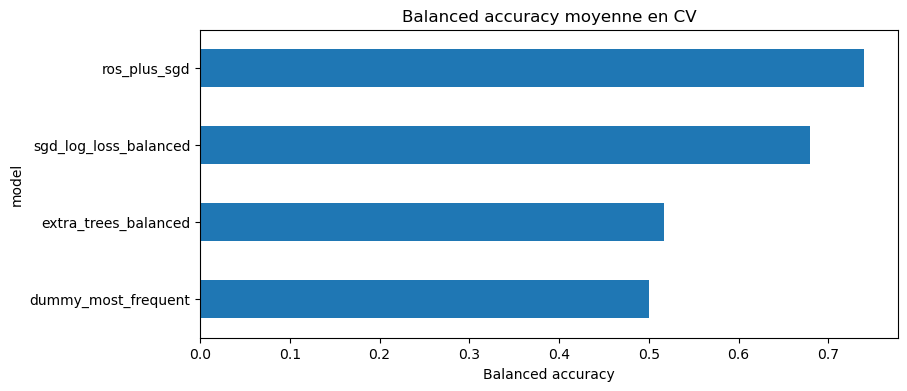

In [14]:
results_cv = evaluate_models(models, X_bench, y_bench, cv_folds=CV_FOLDS)
display(results_cv)

fig, ax = plt.subplots(figsize=(9, 4))
results_cv.set_index("model")["bal_acc_mean"].sort_values().plot(kind="barh", ax=ax)
ax.set_title("Balanced accuracy moyenne en CV")
ax.set_xlabel("Balanced accuracy")
plt.show()

## 10. Choix du meilleur modèle

In [15]:
best_model_name = results_cv.iloc[0]["model"]
best_model = models[best_model_name]

print("Meilleur modèle retenu :", best_model_name)

Meilleur modèle retenu : ros_plus_sgd


## 11. Entraînement sur l'ensemble de développement et évaluation sur validation

In [16]:
best_model.fit(X_dev, y_dev)

y_valid_pred_default = best_model.predict(X_valid)

if hasattr(best_model, "predict_proba"):
    y_valid_score = best_model.predict_proba(X_valid)[:, 1]
else:
    raw_score = best_model.decision_function(X_valid)
    y_valid_score = 1.0 / (1.0 + np.exp(-raw_score))

bal_acc_default = balanced_accuracy_score(y_valid, y_valid_pred_default)
roc_auc = roc_auc_score(y_valid, y_valid_score)

print("Balanced accuracy (seuil par défaut) :", round(bal_acc_default, 4))
print("ROC-AUC :", round(roc_auc, 4))

Balanced accuracy (seuil par défaut) : 0.7397
ROC-AUC : 0.8094


## 12. Optimisation simple du seuil de décision

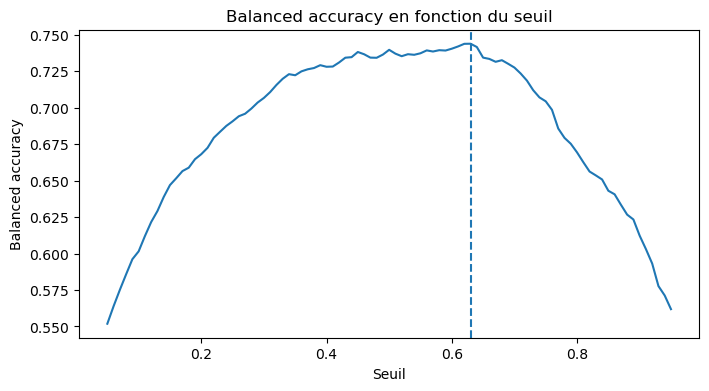

Meilleur seuil : 0.63


In [17]:
best_threshold, threshold_table = find_best_threshold(y_valid, y_valid_score)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(threshold_table["threshold"], threshold_table["balanced_accuracy"])
ax.axvline(best_threshold, linestyle="--")
ax.set_title("Balanced accuracy en fonction du seuil")
ax.set_xlabel("Seuil")
ax.set_ylabel("Balanced accuracy")
plt.show()

print("Meilleur seuil :", round(best_threshold, 3))

In [18]:
y_valid_pred = (y_valid_score >= best_threshold).astype(int)

print("Balanced accuracy (seuil optimisé) :", round(balanced_accuracy_score(y_valid, y_valid_pred), 4))
print()
print(classification_report(y_valid, y_valid_pred, digits=4))

Balanced accuracy (seuil optimisé) : 0.7439

              precision    recall  f1-score   support

           0     0.9849    0.8455    0.9099     15441
           1     0.1308    0.6422    0.2174       559

    accuracy                         0.8384     16000
   macro avg     0.5579    0.7439    0.5636     16000
weighted avg     0.9551    0.8384    0.8857     16000



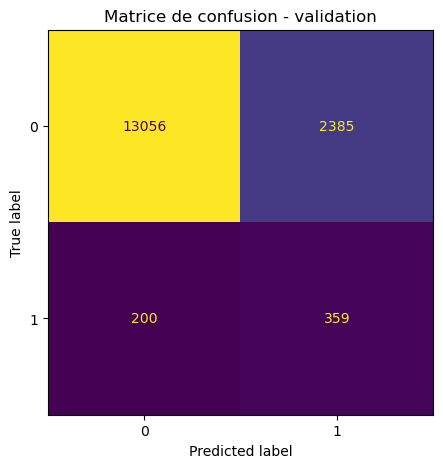

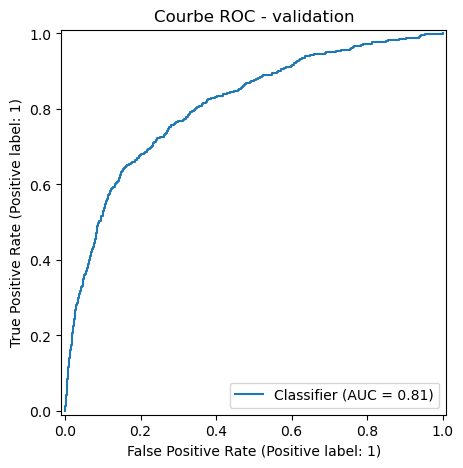

In [19]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_valid, y_valid_pred, ax=ax, colorbar=False)
ax.set_title("Matrice de confusion - validation")
plt.show()

fig, ax = plt.subplots(figsize=(5, 5))
RocCurveDisplay.from_predictions(y_valid, y_valid_score, ax=ax)
ax.set_title("Courbe ROC - validation")
plt.show()

## 13. Refit final pour la soumission

In [20]:
if FINAL_FIT_SAMPLE is None:
    X_final, y_final = X, y
else:
    X_final, y_final = subsample_stratified(
        X,
        y,
        n_rows=FINAL_FIT_SAMPLE,
        random_state=RANDOM_STATE,
    )

print("Taille d'entraînement final :", X_final.shape)

final_model = models[best_model_name]
final_model.fit(X_final, y_final)

Taille d'entraînement final : (79999, 342)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['GENDER', 'AGE',
                                                   'HR_MIN_DAY1', 'HR_MAX_DAY1',
                                                   'HR_MEAN_DAY1',
                                                   'SYS_BP_MIN_DAY1',
                                                   'SYS_BP_MAX_DAY1',
                                                   'SYS_BP_MEAN_DAY1',
                                                   'DIAS_BP_MIN_DAY1',
                                                   'DIAS_BP_MAX_DAY1',
                                                   'DIAS_BP_MEAN_DAY1',
                                                   'MEAN_BP_MIN_DAY1',
                                                   'MEAN...
                                                   'HR_MEAN_DAY2',
                                                   'SYS_BP_MIN_DAY2', ...]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['INSURANCE', 'LANGUAGE',
                                                   'RELIGION', 'MARITAL_STATUS',
                                                   'ETHNICITY', 'ICU'])])),
                ('ros', RandomOverSampler(random_state=42)),
                ('model',
                 SGDClassifier(loss='log_loss', max_iter=1500,
                               random_state=42))])

## 14. Prédictions sur le jeu de test et export

In [21]:
if hasattr(final_model, "predict_proba"):
    test_score = final_model.predict_proba(X_test)[:, 1]
else:
    raw_score = final_model.decision_function(X_test)
    test_score = 1.0 / (1.0 + np.exp(-raw_score))

test_pred = (test_score >= best_threshold).astype(int)

submission = pd.DataFrame(
    {
        "pred_label": test_pred,
        "pred_score": test_score,
    }
)

submission_path = DATA / "submission_survival.csv"
submission.to_csv(submission_path, index=False)

print("Fichier enregistré :", submission_path)
display(submission.head())

Fichier enregistré : /home/imal/ICU-Survival-Prediction-End-to-End-ML-Pipeline/data/public_data/submission_survival.csv


,pred_label,pred_score
0,1,0.874595
1,0,0.490658
2,0,0.041001
3,0,0.304940
4,0,0.255175


## 15. Conclusion rapide

Ce notebook est plus solide que la version initiale parce que :

- les fichiers sont chargés correctement ;
- les types sont imposés proprement à partir des métadonnées ;
- le prétraitement est séparé selon le type de modèle ;
- la comparaison des modèles se fait sur un benchmark stratifié, donc sans surcharger le kernel ;
- l'évaluation finale est propre :
  - balanced accuracy,
  - ROC-AUC,
  - matrice de confusion,
  - optimisation du seuil ;
- la génération du fichier de soumission est intégrée.

### Réglages utiles si la machine est fragile
- diminuer `MODEL_SELECTION_SAMPLE` à `10000` ;
- mettre `FINAL_FIT_SAMPLE = 30000` ;
- réduire `n_estimators` de `ExtraTreesClassifier`.

### Réglages utiles si la machine tient bien
- augmenter `CV_FOLDS` à `5` ;
- augmenter `MODEL_SELECTION_SAMPLE` ;
- tester plus d'hyperparamètres.